# Análisis Exploratorio: Dengue, Precipitación y ONI
**Municipio:** 81001 · **Período:** 2013–2023

Orden de análisis:
1. Serie temporal (tres series apiladas)
2. Correlación cruzada: casos vs precipitación
3. Correlación cruzada: casos vs ONI
4. Diagrama de dispersión con el mejor lag

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr

# ── Configuración ─────────────────────────────────────────────────────────
DATASET_PATH = r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon\ETL_code\dashboard_3\processed\dataset_81001_2013_2023.parquet"
MUNI_CODE    = "81001"
MAX_LAG      = 10   # meses de rezago máximo a evaluar

COLORES = {
    "dengue":  "#E24B4A",
    "precip":  "#185FA5",
    "oni":     "#333333",
    "nino":    "rgba(226,75,74,0.08)",
    "nina":    "rgba(24,95,165,0.08)",
}

NOMBRES_MESES = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})

In [2]:
# ── Carga del dataset ─────────────────────────────────────────────────────
df = pd.read_parquet(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Registros: {len(df)}")
print(f"Período  : {df['date'].min().strftime('%b %Y')} – {df['date'].max().strftime('%b %Y')}")
print(f"Casos totales de dengue: {df['casos'].sum():,}")
print(f"Meses con casos > 0    : {(df['casos'] > 0).sum()}")
print(f"Meses sin ONI (NaN)    : {df['value_oni'].isna().sum()}")
print(f"Meses sin precip (NaN) : {df['precip_mean_mm'].isna().sum()}")
df.head()

Registros: 132
Período  : Jan 2013 – Dec 2023
Casos totales de dengue: 760
Meses con casos > 0    : 106
Meses sin ONI (NaN)    : 0
Meses sin precip (NaN) : 0


,date,muni_code,anio,precip_mean_mm,precip_min,precip_max,std_dev,n_pixels,cod_eve,casos,value_oni
0,2013-01-01,81001,2013,2.893234,1.292323,5.401594,0.752852,241,210,25,-0.29
1,2013-02-01,81001,2013,5.548187,2.646299,11.812715,2.171854,241,210,10,-0.29
2,2013-03-01,81001,2013,81.006325,53.215252,127.573380,11.624427,241,210,26,-0.21
3,2013-04-01,81001,2013,149.217972,102.487732,199.368057,20.714626,241,210,27,-0.19
4,2013-05-01,81001,2013,260.792389,220.701691,303.171814,13.453955,241,210,33,-0.27


## 1. Serie temporal: casos de dengue, precipitación y ONI

C:\Users\laura\AppData\Local\Temp\ipykernel_19012\3892844367.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


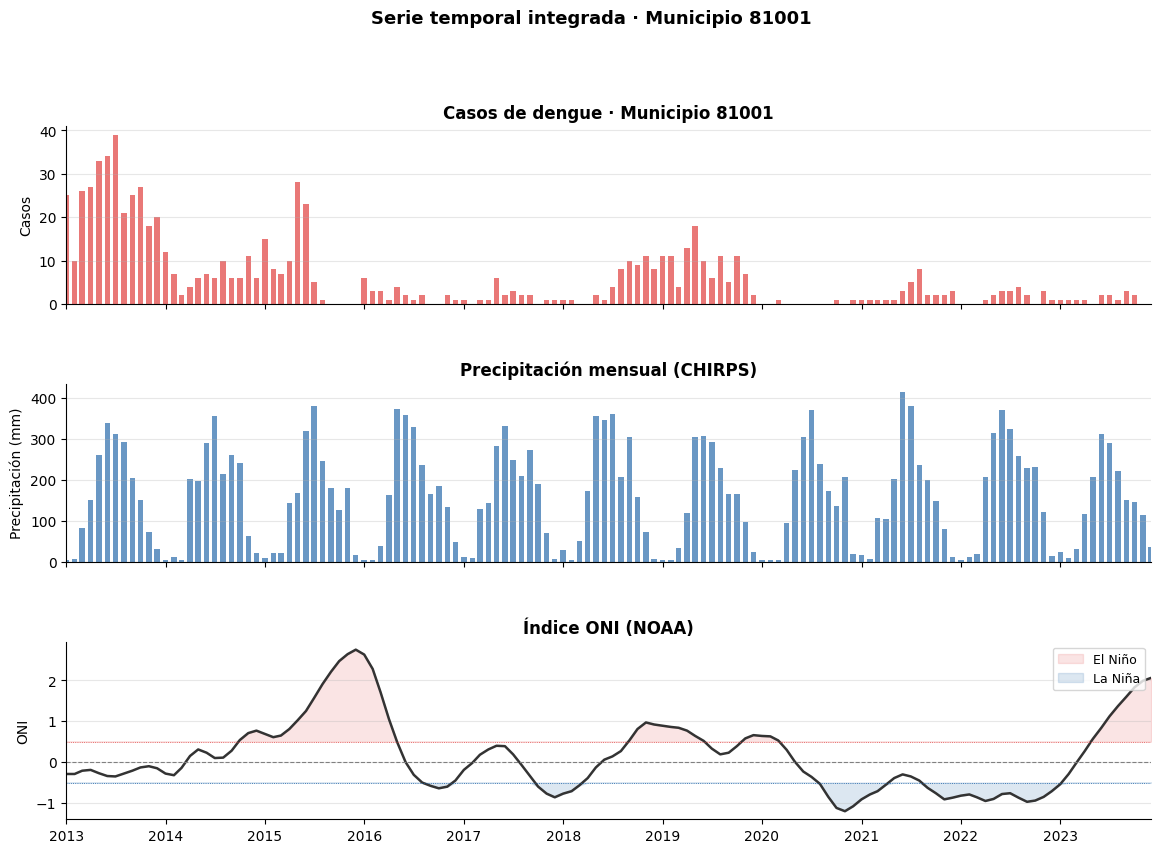

In [3]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])  # Dengue
ax2 = fig.add_subplot(gs[1])  # Precipitación
ax3 = fig.add_subplot(gs[2])  # ONI

# ── Dengue ────────────────────────────────────────────────────────────────
ax1.bar(df["date"], df["casos"],
        color=COLORES["dengue"], alpha=0.75, width=20)
ax1.set_ylabel("Casos")
ax1.set_title(f"Casos de dengue · Municipio {MUNI_CODE}", fontweight="bold")
ax1.tick_params(labelbottom=False)

# ── Precipitación ─────────────────────────────────────────────────────────
ax2.bar(df["date"], df["precip_mean_mm"],
        color=COLORES["precip"], alpha=0.65, width=20)
ax2.set_ylabel("Precipitación (mm)")
ax2.set_title("Precipitación mensual (CHIRPS)", fontweight="bold")
ax2.tick_params(labelbottom=False)

# ── ONI ───────────────────────────────────────────────────────────────────
ax3.plot(df["date"], df["value_oni"],
         color=COLORES["oni"], linewidth=1.8)
ax3.axhline(0,    color="gray", linewidth=0.8, linestyle="--")
ax3.axhline(0.5,  color=COLORES["dengue"], linewidth=0.6, linestyle=":")
ax3.axhline(-0.5, color=COLORES["precip"], linewidth=0.6, linestyle=":")
ax3.fill_between(df["date"], 0.5, df["value_oni"].clip(lower=0.5),
                 color=COLORES["dengue"], alpha=0.15, label="El Niño")
ax3.fill_between(df["date"], -0.5, df["value_oni"].clip(upper=-0.5),
                 color=COLORES["precip"], alpha=0.15, label="La Niña")
ax3.set_ylabel("ONI")
ax3.set_title("Índice ONI (NOAA)", fontweight="bold")
ax3.legend(fontsize=9, loc="upper right")

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(df["date"].min(), df["date"].max())
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Serie temporal integrada · Municipio {MUNI_CODE}",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 2. Correlación cruzada: casos de dengue vs precipitación

In [4]:
def correlacion_cruzada(serie_x: pd.Series, serie_y: pd.Series,
                        max_lag: int = 6) -> pd.DataFrame:
    """
    Calcula la correlación de Pearson entre serie_x desplazada (lag)
    y serie_y para lags de 0 a max_lag.

    Interpretación: lag positivo significa que serie_x de hace N meses
    predice serie_y de hoy.
    """
    resultados = []
    for lag in range(0, max_lag + 1):
        x_lag = serie_x.shift(lag)
        mask  = x_lag.notna() & serie_y.notna()
        if mask.sum() < 20:
            continue
        r, p = pearsonr(x_lag[mask], serie_y[mask])
        resultados.append({
            "lag":         lag,
            "correlacion": round(r, 4),
            "p_valor":     round(p, 4),
            "significativo": p < 0.05,
        })
    return pd.DataFrame(resultados)


df_corr_precip = correlacion_cruzada(
    df["precip_mean_mm"], df["casos"], max_lag=MAX_LAG
)
print("Correlación casos ~ precipitación por lag:")
print(df_corr_precip.to_string(index=False))

lag_opt_precip = df_corr_precip.loc[
    df_corr_precip["correlacion"].abs().idxmax()
]
print(f"\n★ Lag óptimo: {int(lag_opt_precip['lag'])} meses "
      f"(r = {lag_opt_precip['correlacion']:.4f}, "
      f"p = {lag_opt_precip['p_valor']:.4f})")

Correlación casos ~ precipitación por lag:
 lag  correlacion  p_valor  significativo
   0       0.1083   0.2165          False
   1       0.0868   0.3244          False
   2       0.0243   0.7840          False
   3      -0.0301   0.7351          False
   4      -0.0595   0.5046          False
   5      -0.1102   0.2176          False
   6      -0.1080   0.2288          False

★ Lag óptimo: 5 meses (r = -0.1102, p = 0.2176)


TypeError: alpha must be numeric or None, not <class 'list'>

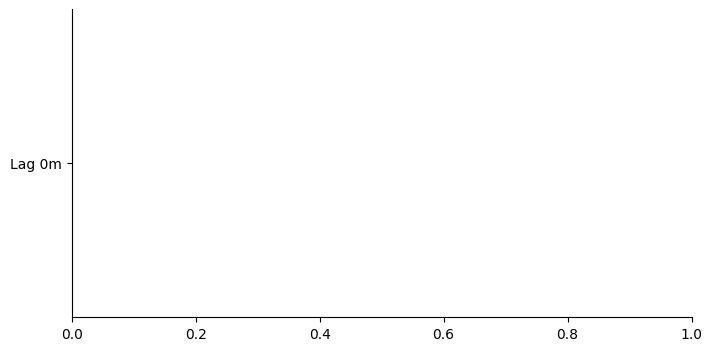

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

colores_barras = [
    COLORES["dengue"] if r < 0 else COLORES["precip"]
    for r in df_corr_precip["correlacion"]
]
opacidades = [
    0.85 if sig else 0.30
    for sig in df_corr_precip["significativo"]
]

bars = ax.barh(
    [f"Lag {l}m" for l in df_corr_precip["lag"]],
    df_corr_precip["correlacion"],
    color=colores_barras,
    alpha=opacidades,
)

# Resaltar lag óptimo
idx_opt = df_corr_precip["correlacion"].abs().idxmax()
bars[idx_opt].set_linewidth(2)
bars[idx_opt].set_edgecolor("black")

ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson")
ax.set_xlim(-1, 1)
ax.set_title("Correlación cruzada: precipitación → casos de dengue",
             fontweight="bold")
ax.text(0.02, -0.15,
        "Barras atenuadas: p > 0.05 (no significativo)",
        transform=ax.transAxes, fontsize=8, color="gray")
ax.yaxis.set_inverted(True)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Correlación cruzada: casos de dengue vs ONI

In [6]:
df_corr_oni = correlacion_cruzada(
    df["value_oni"], df["casos"], max_lag=MAX_LAG
)
print("Correlación casos ~ ONI por lag:")
print(df_corr_oni.to_string(index=False))

lag_opt_oni = df_corr_oni.loc[
    df_corr_oni["correlacion"].abs().idxmax()
]
print(f"\n★ Lag óptimo: {int(lag_opt_oni['lag'])} meses "
      f"(r = {lag_opt_oni['correlacion']:.4f}, "
      f"p = {lag_opt_oni['p_valor']:.4f})")

Correlación casos ~ ONI por lag:
 lag  correlacion  p_valor  significativo
   0       0.0303   0.7302          False
   1       0.0360   0.6832          False
   2       0.0299   0.7357          False
   3       0.0277   0.7557          False
   4       0.0245   0.7838          False
   5       0.0230   0.7971          False
   6       0.0159   0.8599          False

★ Lag óptimo: 1 meses (r = 0.0360, p = 0.6832)


TypeError: alpha must be numeric or None, not <class 'list'>

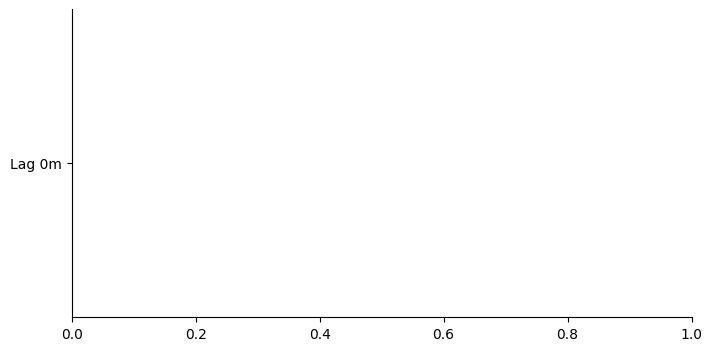

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

colores_barras = [
    COLORES["dengue"] if r < 0 else COLORES["precip"]
    for r in df_corr_oni["correlacion"]
]
opacidades = [
    0.85 if sig else 0.30
    for sig in df_corr_oni["significativo"]
]

bars = ax.barh(
    [f"Lag {l}m" for l in df_corr_oni["lag"]],
    df_corr_oni["correlacion"],
    color=colores_barras,
    alpha=opacidades,
)

idx_opt = df_corr_oni["correlacion"].abs().idxmax()
bars[idx_opt].set_linewidth(2)
bars[idx_opt].set_edgecolor("black")

ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson")
ax.set_xlim(-1, 1)
ax.set_title("Correlación cruzada: ONI → casos de dengue",
             fontweight="bold")
ax.text(0.02, -0.15,
        "Barras atenuadas: p > 0.05 (no significativo)",
        transform=ax.transAxes, fontsize=8, color="gray")
ax.yaxis.set_inverted(True)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Diagrama de dispersión con el mejor lag

Usa el lag óptimo identificado en las correlaciones cruzadas para
visualizar la forma de la relación entre precipitación/ONI y casos.

In [8]:
lag_precip = int(lag_opt_precip["lag"])
lag_oni    = int(lag_opt_oni["lag"])

df_scatter = df[["date", "casos", "precip_mean_mm", "value_oni",
                 "value_oni"]].copy()
df_scatter["precip_lag"] = df_scatter["precip_mean_mm"].shift(lag_precip)
df_scatter["oni_lag"]    = df_scatter["value_oni"].shift(lag_oni)
df_scatter = df_scatter.dropna(subset=["precip_lag", "oni_lag"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Dispersión: precipitación lag óptimo vs casos ─────────────────────────
ax1.scatter(
    df_scatter["precip_lag"],
    df_scatter["casos"],
    color=COLORES["precip"], alpha=0.6, edgecolors="white", s=50,
)
# Línea de tendencia
m, b = np.polyfit(df_scatter["precip_lag"], df_scatter["casos"], 1)
x_line = np.linspace(df_scatter["precip_lag"].min(),
                     df_scatter["precip_lag"].max(), 100)
ax1.plot(x_line, m * x_line + b,
         color=COLORES["precip"], linewidth=1.5, linestyle="--")
r_precip = lag_opt_precip["correlacion"]
p_precip = lag_opt_precip["p_valor"]
ax1.set_xlabel(f"Precipitación lag {lag_precip}m (mm)")
ax1.set_ylabel("Casos de dengue")
ax1.set_title(
    f"Precipitación (lag {lag_precip}m) vs Dengue\n"
    f"r = {r_precip:.3f} · p = {p_precip:.4f}",
    fontweight="bold",
)
ax1.grid(alpha=0.3)

# ── Dispersión: ONI lag óptimo vs casos ───────────────────────────────────
ax2.scatter(
    df_scatter["oni_lag"],
    df_scatter["casos"],
    color=COLORES["oni"], alpha=0.6, edgecolors="white", s=50,
)
m2, b2 = np.polyfit(df_scatter["oni_lag"], df_scatter["casos"], 1)
x_line2 = np.linspace(df_scatter["oni_lag"].min(),
                      df_scatter["oni_lag"].max(), 100)
ax2.plot(x_line2, m2 * x_line2 + b2,
         color=COLORES["oni"], linewidth=1.5, linestyle="--")
r_oni = lag_opt_oni["correlacion"]
p_oni = lag_opt_oni["p_valor"]
ax2.set_xlabel(f"ONI lag {lag_oni}m")
ax2.set_ylabel("Casos de dengue")
ax2.set_title(
    f"ONI (lag {lag_oni}m) vs Dengue\n"
    f"r = {r_oni:.3f} · p = {p_oni:.4f}",
    fontweight="bold",
)
ax2.grid(alpha=0.3)

plt.suptitle(
    f"Diagramas de dispersión con lag óptimo · Municipio {MUNI_CODE}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

ValueError: Cannot set a DataFrame with multiple columns to the single column oni_lag

## Resumen de resultados

In [9]:
print("=" * 55)
print(f"RESUMEN · Municipio {MUNI_CODE}")
print("=" * 55)
print(f"Período analizado      : "
      f"{df['date'].min().strftime('%b %Y')} – "
      f"{df['date'].max().strftime('%b %Y')}")
print(f"Total casos dengue     : {df['casos'].sum():,}")
print()
print("Correlación cruzada precipitación → dengue:")
print(df_corr_precip.to_string(index=False))
print()
print("Correlación cruzada ONI → dengue:")
print(df_corr_oni.to_string(index=False))
print()
print(f"★ Lag óptimo precipitación : {lag_precip} meses "
      f"(r = {r_precip:.3f}, p = {p_precip:.4f})")
print(f"★ Lag óptimo ONI           : {lag_oni} meses "
      f"(r = {r_oni:.3f}, p = {p_oni:.4f})")
print("=" * 55)

RESUMEN · Municipio 81001
Período analizado      : Jan 2013 – Dec 2023
Total casos dengue     : 760

Correlación cruzada precipitación → dengue:
 lag  correlacion  p_valor  significativo
   0       0.1083   0.2165          False
   1       0.0868   0.3244          False
   2       0.0243   0.7840          False
   3      -0.0301   0.7351          False
   4      -0.0595   0.5046          False
   5      -0.1102   0.2176          False
   6      -0.1080   0.2288          False

Correlación cruzada ONI → dengue:
 lag  correlacion  p_valor  significativo
   0       0.0303   0.7302          False
   1       0.0360   0.6832          False
   2       0.0299   0.7357          False
   3       0.0277   0.7557          False
   4       0.0245   0.7838          False
   5       0.0230   0.7971          False
   6       0.0159   0.8599          False



NameError: name 'r_precip' is not defined

## correlacion SPERMAN

In [15]:
from scipy.stats import spearmanr
# Correlación ONI → dengue
df_corr_oni = correlacion_cruzada(
    df["value_oni"], df["casos"], max_lag=MAX_LAG
)
print("Correlación Spearman casos ~ ONI por lag:")
print(df_corr_oni.to_string(index=False))

lag_opt_oni = df_corr_oni.loc[
    df_corr_oni["correlacion"].abs().idxmax()
]
print(f"\n★ Lag óptimo: {int(lag_opt_oni['lag'])} meses "
      f"(r = {lag_opt_oni['correlacion']:.4f}, "
      f"p = {lag_opt_oni['p_valor']:.4f})")



def correlacion_cruzada(serie_x: pd.Series, serie_y: pd.Series,
                        max_lag: int = 6) -> pd.DataFrame:
    resultados = []
    for lag in range(0, max_lag + 1):
        x_lag = serie_x.shift(lag)
        mask  = x_lag.notna() & serie_y.notna()
        if mask.sum() < 20:
            continue
        r, p = spearmanr(x_lag[mask], serie_y[mask])
        resultados.append({
            "lag":           lag,
            "correlacion":   round(r, 4),
            "p_valor":       round(p, 4),
            "significativo": p < 0.05,
        })
    return pd.DataFrame(resultados)


# Correlación precipitación → dengue
df_corr_precip = correlacion_cruzada(
    df["precip_mean_mm"], df["casos"], max_lag=MAX_LAG
)
print("Correlación Spearman casos ~ precipitación por lag:")
print(df_corr_precip.to_string(index=False))

lag_opt_precip = df_corr_precip.loc[
    df_corr_precip["correlacion"].abs().idxmax()
]
print(f"\n★ Lag óptimo: {int(lag_opt_precip['lag'])} meses "
      f"(r = {lag_opt_precip['correlacion']:.4f}, "
      f"p = {lag_opt_precip['p_valor']:.4f})")


df_corr_oni_precip = correlacion_cruzada(
    df["value_oni"], df["precip_mean_mm"], max_lag=MAX_LAG
)
print("Correlación Spearman ONI ~ precipitación por lag:")
print(df_corr_oni_precip.to_string(index=False))

Correlación Spearman casos ~ ONI por lag:
 lag  correlacion  p_valor  significativo
   0       0.2428   0.0050           True
   1       0.2428   0.0052           True
   2       0.2253   0.0100           True
   3       0.1885   0.0324           True
   4       0.1456   0.1011          False
   5       0.0865   0.3336          False
   6       0.0294   0.7437          False
   7      -0.0378   0.6756          False
   8      -0.1025   0.2575          False
   9      -0.1613   0.0746          False
  10      -0.1907   0.0354           True

★ Lag óptimo: 0 meses (r = 0.2428, p = 0.0050)
Correlación Spearman casos ~ precipitación por lag:
 lag  correlacion  p_valor  significativo
   0       0.1266   0.1481          False
   1       0.1389   0.1136          False
   2       0.0998   0.2585          False
   3       0.0211   0.8126          False
   4      -0.0577   0.5179          False
   5      -0.1149   0.1982          False
   6      -0.1198   0.1815          False
   7      -0.1084 

In [14]:
import statsmodels.api as sm
print(sm.__version__)

0.14.4
